In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.
Path to dataset files: /kaggle/input/weather-dataset-rattle-package


In [7]:
import os

print(os.listdir(path))


['weatherAUS.csv']


In [8]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "weatherAUS.csv"))
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [9]:


print(df.shape)

print(df.info())

(145460, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       8

# Data Cleaning
Handle Missing Values

In [10]:
print(df.isnull().sum())

# Separate features and target
X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64


# Encode Target Variable

In [11]:
le = LabelEncoder()
y = le.fit_transform(y)   # Yes → 1, No → 0

# Identify Numerical & Categorical Columns

In [12]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Preprocessing Pipeline

In [14]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build Model Pipeline (Logistic Regression)

In [17]:
# Explanation of the error:
# The `ValueError: could not convert string to float: '2013-06-05'` occurs because the `LogisticRegression`
# model, part of the `model_pipeline`, expects all its input features to be numerical.
# However, the 'Date' column in the `X_train` dataset is of 'object' (string) dtype.
# The previously defined `preprocessor`'s `cat_pipeline` only handles missing value imputation for
# categorical columns but does not encode them into a numerical format. As a result, the 'Date' column
# with string values like '2013-06-05' is passed to the `LogisticRegression` classifier,
# which then attempts to convert these strings to floats, leading to the `ValueError`.

# Fix:
# To resolve this, we need to modify the preprocessing step within the pipeline.
# For the 'Date' column, which is a high-cardinality categorical feature (many unique dates),
# it's often best to either extract specific numerical features (like year, month, day) or drop it
# if the raw date string itself doesn't contribute directly to the prediction.
# For other categorical columns, One-Hot Encoding is a suitable method to convert them into a numerical format.

# We will redefine the ColumnTransformer (`preprocessor`) to:
# 1. Apply numerical pipeline (imputation + scaling) to numerical columns.
# 2. Apply a categorical pipeline (imputation + one-hot encoding) to remaining categorical columns (excluding 'Date').
# 3. Explicitly drop the 'Date' column.

# Re-identifying column types from the original X to ensure 'Date' is handled separately.
# These will correctly refer to the global X.
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Remove 'Date' from the list of features to be one-hot encoded, as it will be dropped.
if 'Date' in categorical_features:
    categorical_features.remove('Date')

# Importing OneHotEncoder, which is needed for the categorical pipeline.
from sklearn.preprocessing import OneHotEncoder

# Reusing the num_pipeline defined earlier (imputer, scaler)
# Redefining the categorical pipeline to include OneHotEncoder.
fixed_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse_output=False returns a dense array
])

# Re-create the ColumnTransformer with the modified handling for 'Date' and other categorical features.
# The `num_pipeline` and `cat_pipeline` variables were defined in cell '2JBIOzNS0oCg'
# and `SimpleImputer` and `StandardScaler` were imported in 'PGnzJbqFybPj', so they are available.
fixed_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features), # Applies num_pipeline to numerical columns
        ('cat', fixed_cat_pipeline, categorical_features), # Applies fixed_cat_pipeline to other categorical columns
        ('drop_date', 'drop', ['Date']) # Explicitly drop the 'Date' column
    ],
    remainder='drop' # Drops any columns not explicitly specified (e.g., if there were others not captured)
)

# Redefine the model_pipeline with the updated preprocessor.
model_pipeline = Pipeline([
    ('preprocessing', fixed_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Now fit the model using the updated pipeline.
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday']),
                                                 ('drop_date', 'drop',
                                                  ['Date'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

# Predictions

In [18]:
y_pred = model_pipeline.predict(X_test)

# Model Evaluation

Accuracy: 0.8288532930015124

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.90     22063
           1       0.72      0.51      0.60      6376
           2       0.25      0.04      0.07       653

    accuracy                           0.83     29092
   macro avg       0.61      0.50      0.52     29092
weighted avg       0.81      0.83      0.81     29092



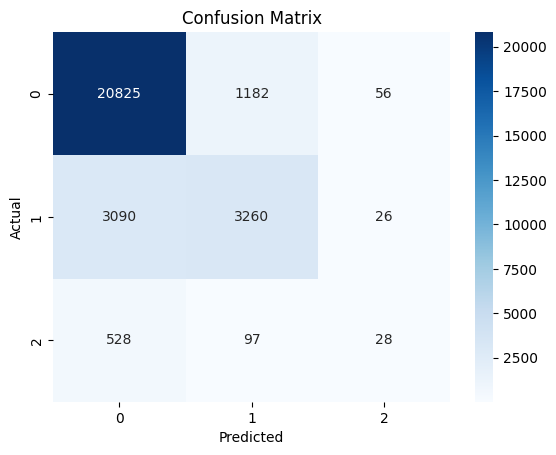

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Random Forest (Better Performance)

In [21]:
rf_pipeline = Pipeline([
    ('preprocessing', fixed_preprocessor), # Use the fixed preprocessor here
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8437027361473944

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.90     22063
           1       0.77      0.50      0.61      6376
           2       0.95      0.25      0.40       653

    accuracy                           0.84     29092
   macro avg       0.86      0.57      0.64     29092
weighted avg       0.84      0.84      0.83     29092



# Hyperparameter Tuning

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,     # smaller
    max_depth=15,         # control overfitting
    min_samples_leaf=5,   # smoother trees
    n_jobs=-1,            # use all CPU
    random_state=42
)

rf_pipeline = Pipeline([
    ('preprocessing', fixed_preprocessor), # Use the fixed preprocessor here
    ('classifier', rf_model)
])

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8365530042623401

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.97      0.90     22063
           1       0.78      0.45      0.57      6376
           2       0.95      0.23      0.37       653

    accuracy                           0.84     29092
   macro avg       0.86      0.55      0.61     29092
weighted avg       0.83      0.84      0.82     29092



# Feature Importance (Important for Project Marks)

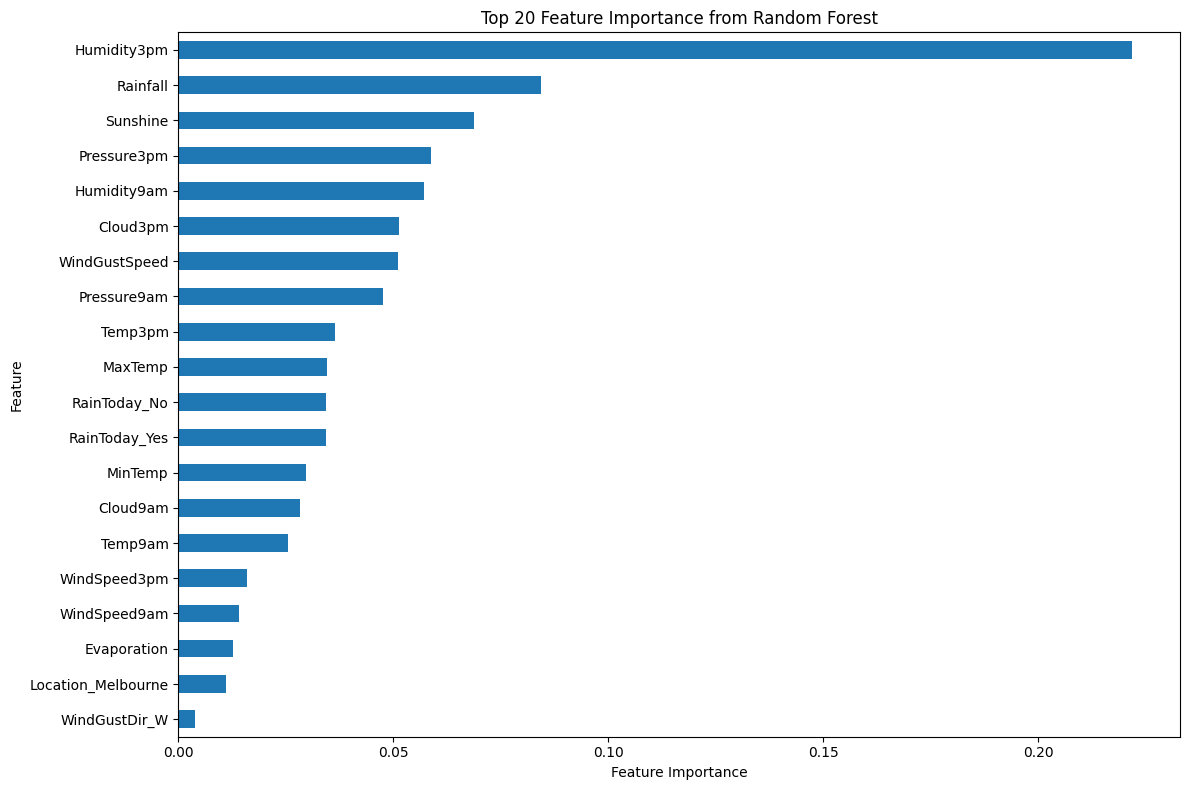

In [29]:
# The 'grid_search' object was not defined in the current execution flow.
# Instead, the Random Forest model was directly trained as 'rf_pipeline' in the previous cell.
# We will use 'rf_pipeline' to extract feature importances.

importances = rf_pipeline.named_steps['classifier'].feature_importances_

# Get the feature names after preprocessing
# The fixed_preprocessor was used, which drops 'Date' and one-hot encodes categorical features.

# 1. Get numerical feature names (from the list 'numerical_features' created in p3_MXx5h0wr6)
final_feature_names = list(numerical_features)

# 2. Get one-hot encoded categorical feature names
# The 'fixed_preprocessor' has a transformer named 'cat' which is a pipeline itself.
# The 'onehot' step within that pipeline can give us the output feature names.
onehot_encoder_step = fixed_preprocessor.named_transformers_['cat'].named_steps['onehot']
# Use the 'categorical_features' list (also created in p3_MXx5h0wr6) as input to get_feature_names_out
final_feature_names.extend(onehot_encoder_step.get_feature_names_out(categorical_features))


# Create a pandas Series for easier sorting and plotting
feature_importances_series = pd.Series(importances, index=final_feature_names)

# Sort features by importance
sorted_importances = feature_importances_series.sort_values(ascending=False)

# Plotting
plt.figure(figsize=(12, 8))
# Plotting top 20 features for better readability, or all if less than 20
num_features_to_plot = min(20, len(sorted_importances))
sorted_importances.head(num_features_to_plot).plot(kind='barh')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(f"Top {num_features_to_plot} Feature Importance from Random Forest")
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()
plt.show()

# Final Model Accuracy

In [31]:
final_pred = y_pred

print("Final Accuracy:", accuracy_score(y_test, final_pred))
print("\nFinal Classification Report:\n", classification_report(y_test, final_pred))

Final Accuracy: 0.8365530042623401

Final Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.97      0.90     22063
           1       0.78      0.45      0.57      6376
           2       0.95      0.23      0.37       653

    accuracy                           0.84     29092
   macro avg       0.86      0.55      0.61     29092
weighted avg       0.83      0.84      0.82     29092



Author
M.Divya dharshini